# Event Camera Data: Exploration Notebook

This notebook is a first hands-on pass at event camera data, following the reading of
Gallego et al., *"Event-based Vision: A Survey"* (IEEE TPAMI 2020). It uses the
[Tonic](https://tonic.readthedocs.io/) library for the standard representations, and can run on
either a public dataset or recordings from our own DAVIS346 camera.

Goals of this notebook:
1. Load event data (N-MNIST, or our own `.aedat4` recordings) and inspect the raw event stream format.
2. Reproduce a few of the standard event *representations* described in the survey
   (Section 3.1): raw events in space-time, event frames / 2D histograms, and time surfaces.
3. Look at voxel grids and multi-modal (event + frame) data, using the DAVIS346's built-in
   grayscale frames when running on our own recordings.

**Data sources.** N-MNIST downloads automatically, is small (34x34 pixels), and needs no
registration, which makes it a good starting point. Our own recordings come from an iniVation
DAVIS346 (346x260 pixels) via the DV software, saved as `.aedat4` files. Switch between them in
the *Choose a data source* cell below; every cell after that works for either.

## 1. Setup

In [1]:
import sys, os
if "google.colab" in sys.modules:
    if not os.path.exists("event-perception"):
        # PLACEHOLDER: replace GITHUB_USER with the GitHub account that hosts this repo
        !git clone -q https://github.com/GITHUB_USER/event-perception.git
    %cd event-perception
    !pip install -q -e .
else:
    # local: assumes `pip install -e .` was run from the repo root
    os.chdir(os.path.dirname(os.path.abspath("")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd())

In [2]:
# tonic is installed without its dependencies on purpose: its metadata pins numpy<2, while
# evcam and everything else here need numpy>=2. The second line adds what tonic actually imports.
!pip install tonic --no-deps -q
!pip install expelliarmus pbr importRosbag -q
import numpy as np
import matplotlib.pyplot as plt
import tonic
import tonic.transforms as transforms

from evcam.io import load_aedat4, crop_time
from evcam.representations import time_surface, event_image

print("tonic version:", tonic.__version__)

tonic version: 1.6.0


## 2. Choose a data source

Set `DATA_SOURCE` to `"nmnist"` for the public dataset, or `"davis"` for one of our own
recordings. For our recordings:

- Put the `.aedat4` file in the repo's `data/` folder and set `RECORDING_PATH`. Recordings are
  kept out of git, so on Colab either upload the file into `event-perception/data/` (Files panel
  on the left) or put it in Google Drive, mount Drive (commented-out lines below), and point
  `RECORDING_PATH` at it.
- A raw recording is several seconds long and contains hundreds of thousands of events per
  second, far more than an N-MNIST sample. The representations below are meant to show a short
  slice of time, so `T_START_S` and `WINDOW_S` pick which slice to analyze. The event-rate plot
  in the next section helps choose `T_START_S`.
- To show a different digit, only this cell needs to change.

In [3]:
DATA_SOURCE = "davis"                 # "nmnist" or "davis"

# --- Settings for our own DAVIS346 recordings ---
RECORDING_PATH = "data/digit4.aedat4" # e.g. "data/digit4.aedat4" or "/content/drive/MyDrive/event_recordings/digit4.aedat4"
RECORDING_LABEL = 4                   # what the recording shows (used only in plot titles)
T_START_S = 2.0                       # start of the analysis window, seconds from start of recording
WINDOW_S = 0.05                       # length of the analysis window, seconds (50 ms is a good start)

# --- Settings for N-MNIST ---
NMNIST_INDEX = 5                      # which test-set sample to use

# Optional: mount Google Drive if the recordings live there
# from google.colab import drive
# drive.mount("/content/drive")

### Loading `.aedat4` recordings

DV saves each camera output as a separate stream inside the `.aedat4` file: the events, the
grayscale APS frames, and (if connected) the IMU. The `aedat` package decodes these into packets.
`load_aedat4` (in `evcam/io.py`) collects the events into the same structured array layout Tonic
uses for N-MNIST, `(x, y, t, p)` with `p` as 0/1, so all the cells after this point work unchanged
on either data source. Timestamps in the file are absolute (microseconds since the Unix epoch),
so they are shifted to start at 0.

Each grayscale frame is returned as a dict with its `image`, its timestamp `t`, and the start and
end of its exposure (`exposure_begin_t`, `exposure_end_t`), all on the same zeroed clock as the
events. The exposure window is what a later deblurring step (EDI) needs in order to pick out the
events that fired while the frame was being exposed. `crop_time` (same file) cuts out a short
time window of events and re-zeroes its timestamps.

## 3. Load a sample and inspect the raw event stream

An event camera does not output frames. Each event is a tuple `(x, y, t, p)`:
- `x, y`: pixel location
- `t`: timestamp (microseconds)
- `p`: polarity, whether the log-brightness increased (ON) or decreased (OFF)

This is exactly the `e_k = (x_k, t_k, p_k)` notation used in Section 2.4 of the survey.

Full recording: 1,640,575 events over 8.06 s (204k events/s), 286 grayscale frames


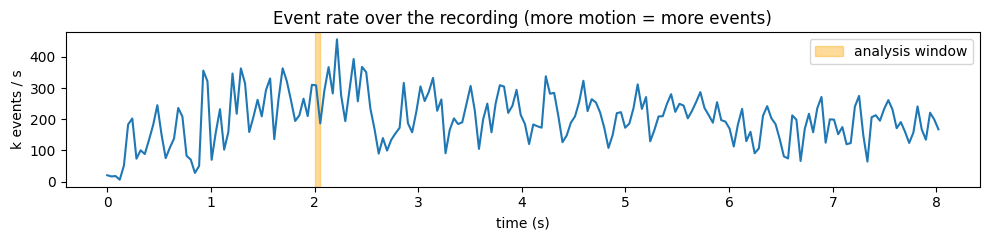

Sensor size (W, H, P): (346, 260, 2)
Label (digit): 4
Number of events in this sample: 17719
Structured dtype: [('x', '<i8'), ('y', '<i8'), ('t', '<i8'), ('p', '<i8')]
First 5 events (x, y, t, p):
[(183,  16,  8, 1) (207, 127, 12, 0) (219, 117, 19, 0) (  8,  38, 21, 0)
 (211, 155, 23, 0)]


In [4]:
aps_frames = []   # grayscale frames, only available for DAVIS recordings

if DATA_SOURCE == "nmnist":
    sensor_size = tonic.datasets.NMNIST.sensor_size  # (W, H, polarities)
    dataset = tonic.datasets.NMNIST(save_to="./data", train=False)
    print("Number of samples:", len(dataset))
    events, label = dataset[NMNIST_INDEX]

elif DATA_SOURCE == "davis":
    all_events, aps_frames, sensor_size = load_aedat4(RECORDING_PATH)
    label = RECORDING_LABEL
    duration_s = all_events["t"][-1] / 1e6
    print(f"Full recording: {len(all_events):,} events over {duration_s:.2f} s "
          f"({len(all_events) / duration_s / 1e3:.0f}k events/s), {len(aps_frames)} grayscale frames")

    # Event rate over the whole recording, to help pick T_START_S
    counts, edges = np.histogram(all_events["t"] / 1e6, bins=200)
    rate = counts / np.diff(edges) / 1e3
    plt.figure(figsize=(10, 2.5))
    plt.plot(edges[:-1], rate)
    plt.axvspan(T_START_S, T_START_S + WINDOW_S, color="orange", alpha=0.4, label="analysis window")
    plt.xlabel("time (s)"); plt.ylabel("k events / s")
    plt.title("Event rate over the recording (more motion = more events)")
    plt.legend(); plt.tight_layout(); plt.show()

    events = crop_time(all_events, int(T_START_S * 1e6), int(WINDOW_S * 1e6))

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE}")

print("Sensor size (W, H, P):", sensor_size)
print("Label (digit):", label)
print("Number of events in this sample:", len(events))
print("Structured dtype:", events.dtype)
print("First 5 events (x, y, t, p):")
print(events[:5])

Notice how sparse and asynchronous this is. A 34x34 N-MNIST sample of a digit produces a few
thousand events spread over a fraction of a second, rather than a fixed grid of pixel
intensities at a fixed frame rate. A real 346x260 recording produces far more, since there are
~80x more pixels and every edge in the scene (not just the digit) generates events as it moves.

## 4. Representation 1 — raw events in space-time

The most direct way to look at events is as points in an (x, y, t) volume, colored by
polarity. This is Fig. 3(a) in the survey.

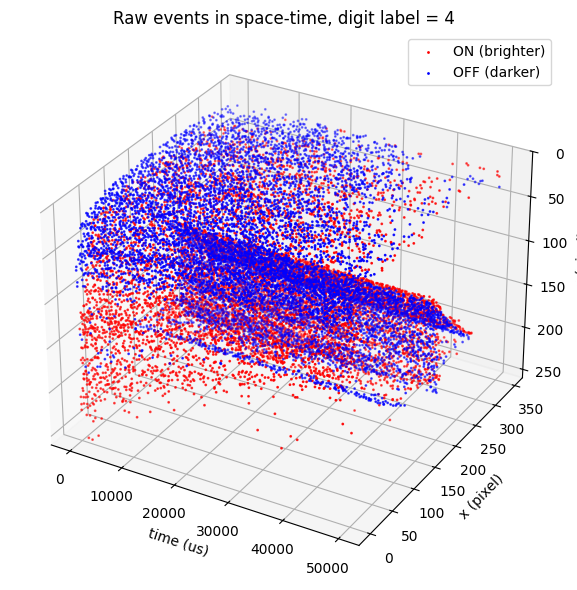

In [5]:
MAX_POINTS = 20000  # 3D scatter gets slow and unreadable beyond this, so subsample if needed

plot_events = events
if len(events) > MAX_POINTS:
    idx = np.sort(np.random.default_rng(0).choice(len(events), MAX_POINTS, replace=False))
    plot_events = events[idx]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

pos = plot_events[plot_events["p"] == 1]
neg = plot_events[plot_events["p"] == 0]

ax.scatter(pos["t"], pos["x"], pos["y"], s=1, c="red", label="ON (brighter)")
ax.scatter(neg["t"], neg["x"], neg["y"], s=1, c="blue", label="OFF (darker)")
ax.set_xlabel("time (us)")
ax.set_ylabel("x (pixel)")
ax.set_zlabel("y (pixel)")
ax.set_zlim(sensor_size[1], 0)  # image convention: y increases downward
ax.set_title(f"Raw events in space-time, digit label = {label}"
             + (f"\n({len(plot_events):,} of {len(events):,} events shown)" if len(events) > MAX_POINTS else ""))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Representation 2 — event frames (2D histograms)

The most common way to make events compatible with standard CV tooling (CNNs, etc.) is to
accumulate events over a short time window into a 2D image. Here each frame is
`ON count - OFF count` per pixel, using Tonic's `ToFrame` transform to bin the stream into
a handful of time windows.

Frames array shape (bins, polarity, H, W): (6, 2, 260, 346)


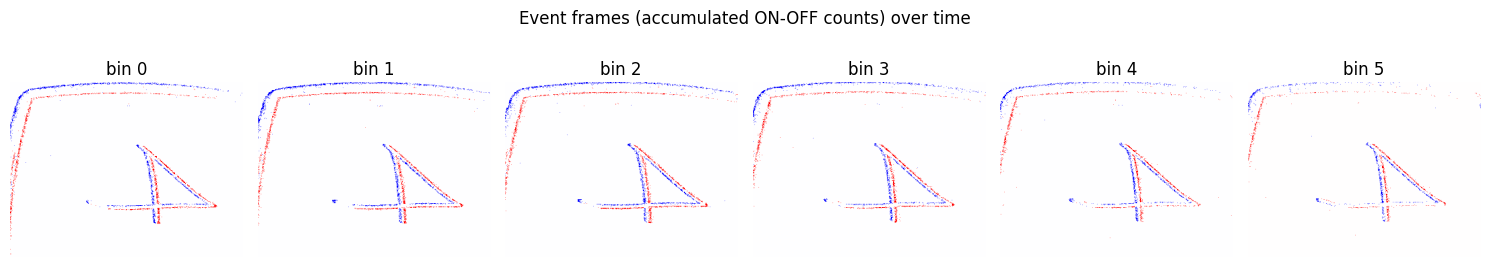

In [6]:
n_bins = 6
frame_transform = transforms.ToFrame(sensor_size=sensor_size, n_time_bins=n_bins)
frames = frame_transform(events)  # shape: (n_bins, polarity, H, W)
print("Frames array shape (bins, polarity, H, W):", frames.shape)

fig, axes = plt.subplots(1, n_bins, figsize=(15, 3))
for i in range(n_bins):
    img = frames[i, 1].astype(float) - frames[i, 0].astype(float)
    axes[i].imshow(img, cmap="bwr", vmin=-2, vmax=2)
    axes[i].set_title(f"bin {i}")
    axes[i].axis("off")
fig.suptitle("Event frames (accumulated ON-OFF counts) over time")
plt.tight_layout()
plt.show()

## 6. Representation 3 — time surface

A time surface stores, per pixel, a value that decays with how long ago that pixel last
fired (Section 3.1 of the survey). It captures short-term motion history in a single 2D
image instead of a stack of frames.

The implementation (`time_surface` in `evcam/representations.py`) is vectorized so it stays fast on real recordings with tens of
thousands of events. Because the decay value only grows with time, "the most recent event at
each pixel" is the same as "the largest decay value at each pixel", which `np.maximum.at`
computes in one call instead of a Python loop.

`tau` sets how long the trail is. For N-MNIST's short samples ~5 ms works well; for a 50 ms
window of real data a longer `tau` (~15 ms) shows more of the motion history.

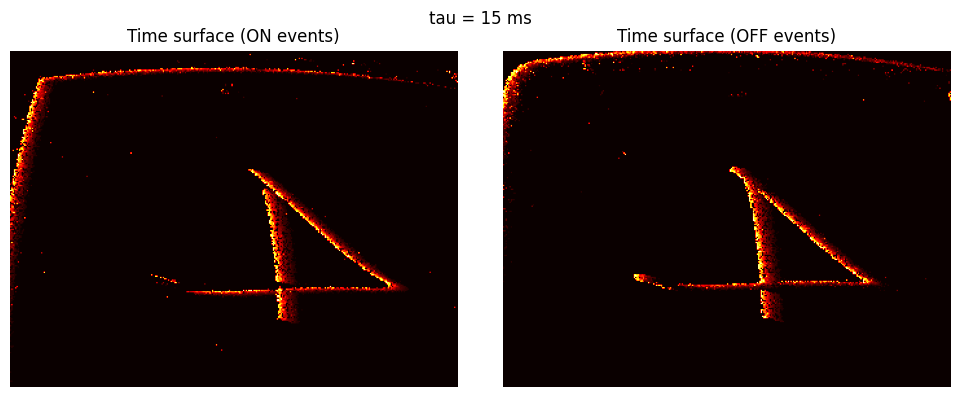

In [7]:
tau = 5000.0 if DATA_SOURCE == "nmnist" else 15000.0
ts_pos, ts_neg = time_surface(events, sensor_size, tau=tau)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(ts_pos, cmap="hot")
axes[0].set_title("Time surface (ON events)")
axes[1].imshow(ts_neg, cmap="hot")
axes[1].set_title("Time surface (OFF events)")
for a in axes:
    a.axis("off")
fig.suptitle(f"tau = {tau / 1000:.0f} ms")
plt.tight_layout()
plt.show()

## 7. Voxel grids and multi-modal (event + frame) data

- **Voxel grids**: instead of collapsing time into a handful of 2D frames, a voxel grid
  keeps a 3D (x, y, t-bin) histogram, which several of the deep-learning optical flow and
  SLAM methods in the paper list use as network input (e.g. EV-FlowNet-style pipelines).
  Tonic provides `transforms.ToVoxelGrid` as a drop-in replacement for `ToFrame` above.
- **Multi-modal event + frame data**: DAVIS cameras output events and low-rate grayscale
  frames from the same pixel array. When running on our own recordings, the last cell of this
  section shows the grayscale frame captured closest to the analysis window next to the events,
  which is the kind of pairing most of the SLAM/VIO papers in the list rely on.

Voxel grid shape (bins, polarity, H, W): (6, 1, 260, 346)


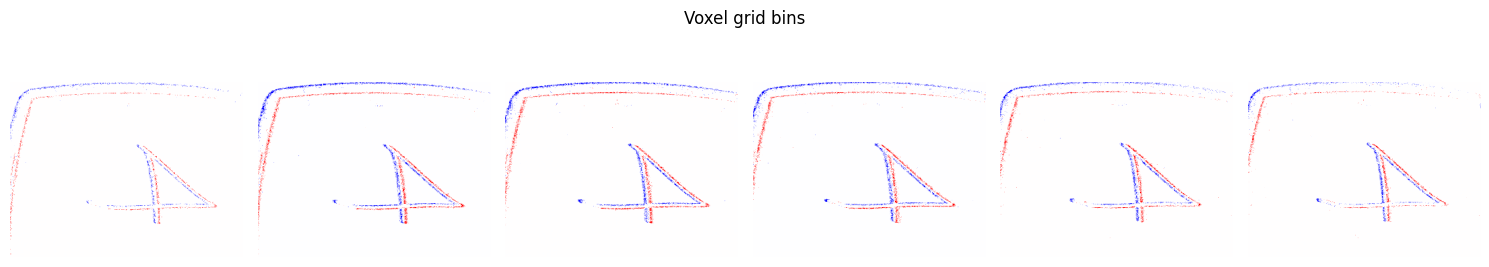

In [8]:
voxel_transform = transforms.ToVoxelGrid(sensor_size=sensor_size, n_time_bins=6)
voxel = voxel_transform(events)
print("Voxel grid shape (bins, polarity, H, W):", voxel.shape)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(voxel[i, 0], cmap="bwr", vmin=-2, vmax=2)
    axes[i].axis("off")
fig.suptitle("Voxel grid bins")
plt.tight_layout()
plt.show()

Voxel grid shape (bins, polarity, H, W): (6, 1, 260, 346)


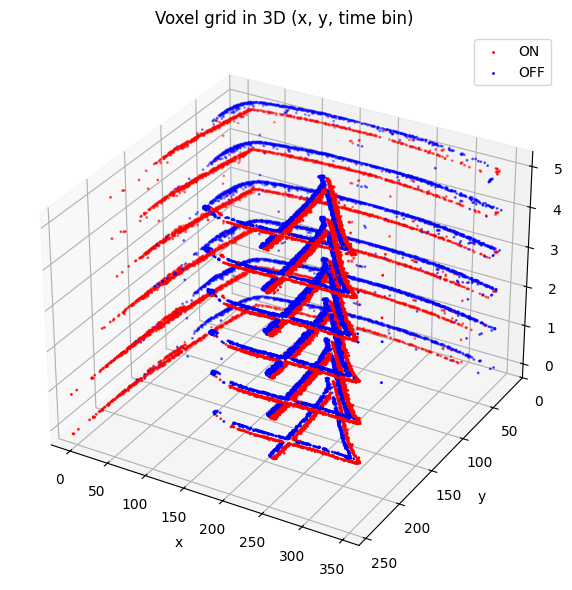

In [9]:
voxel_transform = transforms.ToVoxelGrid(sensor_size=sensor_size, n_time_bins=6)
voxel = voxel_transform(events)
print("Voxel grid shape (bins, polarity, H, W):", voxel.shape)

MAX_POINTS_PER_BIN = 4000  # keep the 3D plot readable on full-resolution recordings
rng = np.random.default_rng(0)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
n_bins = voxel.shape[0]

for i in range(n_bins):
    img = voxel[i, 0]
    ys, xs = np.nonzero(img)
    if len(xs) > MAX_POINTS_PER_BIN:
        keep = rng.choice(len(xs), MAX_POINTS_PER_BIN, replace=False)
        ys, xs = ys[keep], xs[keep]
    vals = img[ys, xs]
    pos_mask = vals > 0
    neg_mask = vals < 0
    s = 10 if DATA_SOURCE == "nmnist" else 1
    ax.scatter(xs[pos_mask], ys[pos_mask], zs=i, zdir="z", c="red", s=s, label="ON" if i == 0 else None)
    ax.scatter(xs[neg_mask], ys[neg_mask], zs=i, zdir="z", c="blue", s=s, label="OFF" if i == 0 else None)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("time bin")
ax.set_ylim(sensor_size[1], 0)
ax.set_title("Voxel grid in 3D (x, y, time bin)")
ax.legend()
plt.tight_layout()
plt.show()

Nearest frame: t = 2.041 s, exposure 2.0409 to 2.0739 s (33.0 ms)


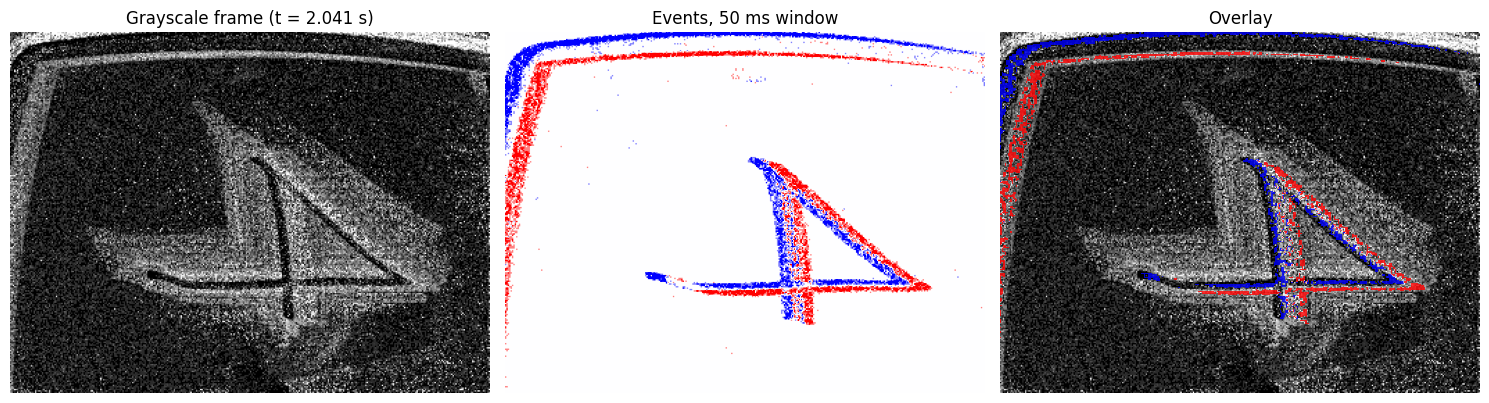

In [10]:
# Grayscale (APS) frame vs. events for the same moment. DAVIS recordings only.
if DATA_SOURCE == "davis" and len(aps_frames) > 0:
    t_center = (T_START_S + WINDOW_S / 2) * 1e6
    frame = min(aps_frames, key=lambda f: abs(f["t"] - t_center))
    nearest_t, gray = frame["t"], frame["image"]
    print(f"Nearest frame: t = {nearest_t / 1e6:.3f} s, exposure "
          f"{frame['exposure_begin_t'] / 1e6:.4f} to {frame['exposure_end_t'] / 1e6:.4f} s "
          f"({(frame['exposure_end_t'] - frame['exposure_begin_t']) / 1e3:.1f} ms)")

    # Stretch contrast so dim lab lighting is still visible
    lo, hi = np.percentile(gray, [1, 99])
    gray_disp = np.clip((gray.astype(float) - lo) / max(hi - lo, 1), 0, 1)

    ev_img = event_image(events, sensor_size)   # ON count - OFF count per pixel

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(gray_disp, cmap="gray")
    axes[0].set_title(f"Grayscale frame (t = {nearest_t / 1e6:.3f} s)")
    axes[1].imshow(ev_img, cmap="bwr", vmin=-2, vmax=2)
    axes[1].set_title(f"Events, {WINDOW_S * 1000:.0f} ms window")
    axes[2].imshow(gray_disp, cmap="gray")
    axes[2].imshow(np.ma.masked_equal(np.sign(ev_img), 0), cmap="bwr", vmin=-1, vmax=1, alpha=0.8)
    axes[2].set_title("Overlay")
    for a in axes:
        a.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No grayscale frames for this data source (N-MNIST is events only).")

## 8. Summary and next steps

What this notebook covers: loading event data (N-MNIST or our own DAVIS346 recordings),
understanding the `(x, y, t, p)` event format, and reproducing three of the standard
representations from the survey (raw events, event frames, time surfaces), plus voxel grids
and a first look at pairing events with the DAVIS grayscale frames.

What it does not cover yet: an actual optical flow / SLAM / generative algorithm running on
this data. The papers in the reference list (E-RAFT, EV-FlowNet, "Secrets of Event-Based Optical
Flow" for optical flow; ESVO2 / DEIO for SLAM/VO; ControlEvents for generative modeling)
each have public code that would be the next thing to get running once one task is
selected. The `load_aedat4` / `crop_time` functions in `evcam/io.py` are reusable for that work.